# Micro-Project 2: Visualizing NVD Vulnerability (CVE) Data

**ANA500 -- Data Science Process**

- **Author:** Christian Cruz
- **Scope:** This notebook covers the **Analyze data** and **Report** steps of the data
science process (visualization with Matplotlib and Plotly), building on the cleaned
dataset produced in Micro-Project 1. Modeling (regression) and applying the results are
out of scope here and will be covered in Micro-Projects 3 and 4 using this same dataset.

## Problem Statement
Security teams face a constantly growing volume of publicly disclosed vulnerabilities,
called Common Vulnerabilities and Exposures (CVEs), and must decide which to patch first
and how to plan analyst capacity to keep up. This connects directly to compliance work
such as NIST 800-53 and CIS hardening baselines. Before a team can make good patching
decisions, they first need to understand the shape of the problem: how fast are new CVEs
appearing, how severe are they, and which structural traits of a CVE record line up with
higher severity.

## Hypothesis Formulation
Structural characteristics of a CVE record, specifically its CVSS attack vector, attack
complexity, and the exploitability and impact sub-scores that make up its overall
severity score, are associated with how severe that CVE is classified as. Separately, the
volume and severity mix of disclosed CVEs is expected to change meaningfully over the
2015 to 2026 window, which would support the idea that patch-prioritization workload is
not staying flat over time. This micro-project uses visualization to explore both parts
of that hypothesis before any formal modeling is attempted in Micro-Project 3.


## Step 1: Acquire (recap from Micro-Project 1)

**Data source:** [`fkie-cad/nvd-json-data-feeds`](https://github.com/fkie-cad/nvd-json-data-feeds),
a community-maintained reconstruction of NIST's National Vulnerability Database bulk JSON
feeds, rebuilt from the official NVD API 2.0. Micro-Project 1 downloaded 12 years of yearly
archives (2015 to 2026) and parsed 321,240 raw CVE records into a flat table.

For this micro-project, the same acquisition and cleaning notebook from Micro-Project 1
was re-run to produce an up-to-date `data/cve_clean.csv`. Because the NVD feed is a live,
continuously updated source, the record count here is slightly higher than what Micro-
Project 1 reported. That is expected and does not change any of the cleaning logic. Full
detail on the acquisition and cleaning steps (handling four incompatible CVSS scoring
standards, the "n/a" placeholder-text bug, dropping withdrawn and unscored records) lives
in the Micro-Project 1 notebook and is only summarized here.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import plotly.express as px
import plotly.io as pio
import os

# Point Plotly's static-image export (Kaleido) at the Chromium browser already
# installed in this environment, instead of downloading a separate copy.
os.environ.setdefault(
    "BROWSER_PATH",
    "/opt/pw-browsers/chromium-1194/chrome-linux/chrome"
)

plt.rcParams["figure.autolayout"] = True
print("Libraries loaded.")

Libraries loaded.


In [2]:
# --------------------------------------------------------------
# Shared chart style, reused across every figure in this notebook so the
# whole report reads as one consistent, deliberately-colored system rather
# than a grab-bag of default chart-library colors.
#
# Categorical colors (used for unordered groups like attack vector or vendor)
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
       "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

# Severity is not just a category, it is an ordered scale from safest to most
# dangerous, so it gets a status-style ramp instead of arbitrary category colors.
STATUS = {"LOW": "#0ca30c", "MEDIUM": "#fab219", "HIGH": "#ec835a", "CRITICAL": "#d03b3b"}
SEVERITY_ORDER = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]

# Diverging blue-to-red scale for the correlation heatmap, where 0 (gray) means
# "no relationship" and the two colors mean "positive" vs "negative" relationship.
DIV_BLUE_RED = ["#0d366b", "#3987e5", "#cde2fb", "#f0efec", "#f5c9c8", "#e34948", "#8a1f1f"]

SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
AXIS_LINE = "#c3c2b7"


def style_ax(ax, y_grid=True, x_grid=False):
    '''Apply the shared look (background, spines, grid, tick colors) to a Matplotlib axis.'''
    ax.set_facecolor(SURFACE)
    ax.figure.set_facecolor(SURFACE)
    for spine_name, spine in ax.spines.items():
        if spine_name in ("top", "right"):
            spine.set_visible(False)
        else:
            spine.set_color(AXIS_LINE)
            spine.set_linewidth(0.8)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    ax.xaxis.label.set_color(INK_SECONDARY)
    ax.yaxis.label.set_color(INK_SECONDARY)
    ax.title.set_color(INK_PRIMARY)
    if y_grid:
        ax.grid(axis="y", color=GRIDLINE, linewidth=0.8, zorder=0)
    if x_grid:
        ax.grid(axis="x", color=GRIDLINE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    return ax


def thousands(ax, axis="y"):
    '''Format axis tick numbers with comma separators, e.g. 10,000 instead of 10000.'''
    fmt = mticker.FuncFormatter(lambda v, p: f"{int(v):,}")
    if axis == "y":
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)


PLOTLY_LAYOUT = dict(
    plot_bgcolor=SURFACE, paper_bgcolor=SURFACE,
    font=dict(color=INK_SECONDARY, size=12),
    title_font=dict(color=INK_PRIMARY, size=16),
    margin=dict(t=60, l=60, r=30, b=60),
)

print("Style helpers ready.")

Style helpers ready.


## Step 2: Prepare (recap from Micro-Project 1)

Loading the cleaned dataset produced above. This is the same 37-column table built in
Micro-Project 1: withdrawn ("Rejected") and unscored CVE records already removed, dates
already parsed, and a unified `primary_score` / `primary_severity` column already derived
across the four CVSS scoring standards (v2, v3.0, v3.1, v4.0).


In [3]:
df = pd.read_csv("data/cve_clean.csv", low_memory=False)
df["published_date"] = pd.to_datetime(df["published_date"])

print(f"Rows: {len(df):,}, Columns: {df.shape[1]}")
df[["cve_id", "published_date", "primary_vendor", "primary_score",
    "primary_severity", "v3_attack_vector"]].head()

Rows: 304,115, Columns: 37


,cve_id,published_date,primary_vendor,primary_score,primary_severity,v3_attack_vector
0,CVE-2015-0001,2015-01-13 22:59:00.050,NaN,1.9,LOW,NaN
1,CVE-2015-0002,2015-01-13 22:59:01.253,NaN,7.2,HIGH,NaN
2,CVE-2015-0003,2015-02-11 03:00:28.763,NaN,6.9,MEDIUM,NaN
3,CVE-2015-0004,2015-01-13 22:59:02.597,NaN,7.2,HIGH,NaN
4,CVE-2015-0005,2015-03-11 10:59:00.087,NaN,4.3,MEDIUM,NaN


## Step 3: Analyze Data

**Choosing chart types.** Following the question-to-chart guidance covered in class, each
visualization below is picked to answer a specific question about the data rather than
just to show a chart: distributions for "what does the spread of a single measure look
like," category comparisons for "how do discrete groups differ," relationships for "how do
two measures move together," change over time for "is this getting better or worse," part-
to-whole for "is the mix changing, not just the volume," and a heatmap for "which measures
move together across the board." Severity (LOW / MEDIUM / HIGH / CRITICAL) is colored the
same way in every chart below, using a fixed green-to-red scale, so severity is always
visually recognizable no matter which chart it appears in.

### 3.1 Distributions


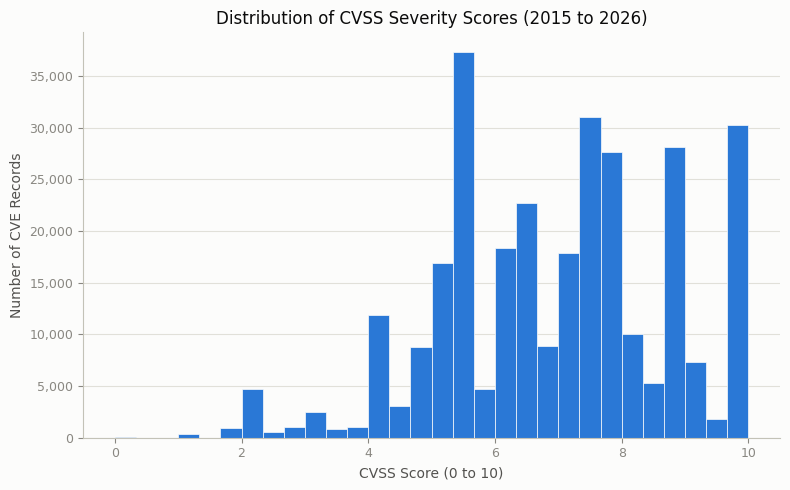

In [4]:
# Histogram: shape of the overall CVSS score distribution.
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["primary_score"], bins=30, color=CAT[0], edgecolor=SURFACE, linewidth=0.5)
ax.set_title("Distribution of CVSS Severity Scores (2015 to 2026)")
ax.set_xlabel("CVSS Score (0 to 10)")
ax.set_ylabel("Number of CVE Records")
style_ax(ax)
thousands(ax)
plt.show()

**Reading this chart:** Scores cluster in the 5 to 9 range rather than spreading
evenly across 0 to 10. Very few CVEs score below 3, meaning the "low severity" end of the
scale is rare in practice. There is a visible bump in the far right around a score of 10,
the maximum possible score, which is worth keeping in mind for Micro-Project 3's
regression work since it means the score is not smoothly continuous everywhere.


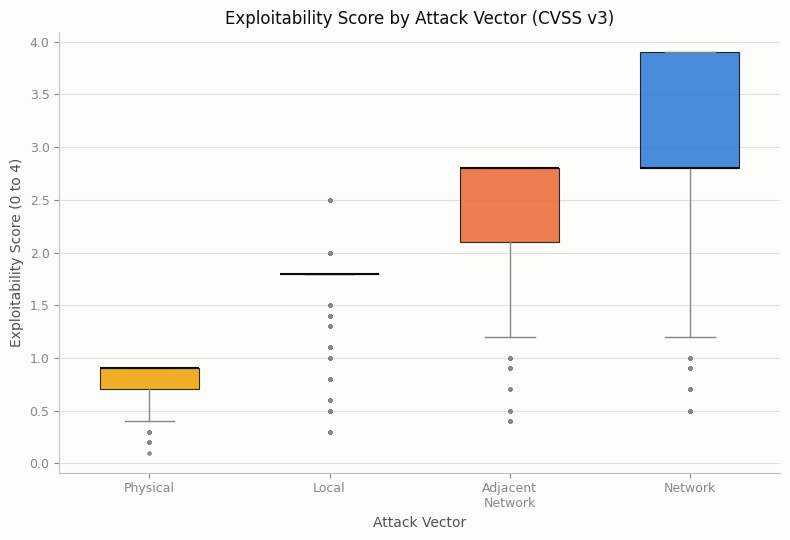

In [5]:
# Box plot: how the CVSS v3 exploitability sub-score varies by attack vector.
# (grouped distribution comparison, directly tests part of the hypothesis)
order = ["PHYSICAL", "LOCAL", "ADJACENT_NETWORK", "NETWORK"]
order_labels = ["Physical", "Local", "Adjacent\nNetwork", "Network"]
sub = df[df["v3_attack_vector"].isin(order)]
box_colors = [CAT[3], CAT[2], CAT[1], CAT[0]]

fig, ax = plt.subplots(figsize=(8, 5.5))
bp = ax.boxplot(
    [sub.loc[sub["v3_attack_vector"] == o, "v3_exploitability_score"].dropna() for o in order],
    tick_labels=order_labels, patch_artist=True, widths=0.55,
    medianprops=dict(color=INK_PRIMARY, linewidth=1.5),
    whiskerprops=dict(color=INK_MUTED), capprops=dict(color=INK_MUTED),
    flierprops=dict(markerfacecolor=INK_MUTED, markeredgecolor="none", markersize=3, alpha=0.4),
)
for patch, c in zip(bp["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.85)
    patch.set_edgecolor(INK_PRIMARY)
    patch.set_linewidth(0.8)

ax.set_title("Exploitability Score by Attack Vector (CVSS v3)")
ax.set_xlabel("Attack Vector")
ax.set_ylabel("Exploitability Score (0 to 4)")
style_ax(ax)
plt.show()

**Reading this chart:** This directly supports the hypothesis. CVEs that can be
exploited remotely over a Network have a much higher and tighter exploitability score
(median around 2.8) than CVEs that require Local or Physical access. This makes intuitive
sense: an attacker does not need to be near the target for a network-exploitable
vulnerability, so it is treated as easier to exploit by design. Attack vector is a strong,
usable predictor candidate for the regression model planned in Micro-Project 3.


### 3.2 Category Comparisons


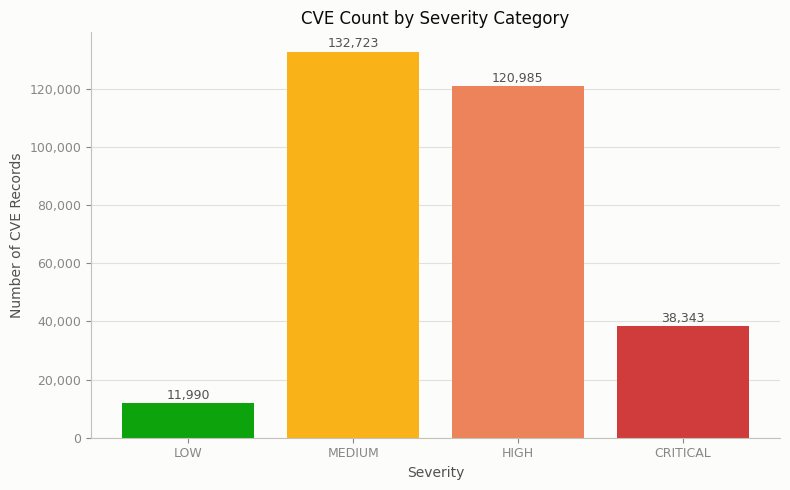

In [6]:
# Bar chart: how many CVEs fall into each severity category.
counts = df["primary_severity"].value_counts().reindex(SEVERITY_ORDER)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values, color=[STATUS[s] for s in counts.index])
ax.set_title("CVE Count by Severity Category")
ax.set_xlabel("Severity")
ax.set_ylabel("Number of CVE Records")
style_ax(ax)
thousands(ax)
for b in bars:
    h = b.get_height()
    ax.annotate(f"{int(h):,}", (b.get_x() + b.get_width() / 2, h), xytext=(0, 3),
                textcoords="offset points", ha="center", fontsize=9, color=INK_SECONDARY)
plt.show()

**Reading this chart:** MEDIUM and HIGH severity CVEs dominate the dataset, together
making up over 80 percent of all records. CRITICAL CVEs, while the smallest of the four
main groups, still total over 38,000 records, which is far too many for any team to patch
one at a time without some form of prioritization.


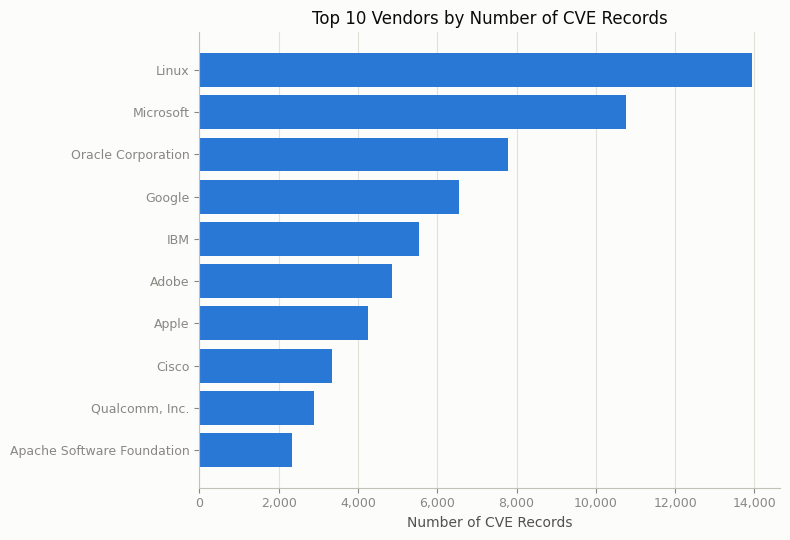

In [7]:
# Horizontal bar: which vendors show up most often in CVE records.
# "Unknown" is excluded since it is a data-quality placeholder, not a real vendor.
vend = (df.loc[df["primary_vendor"].notna() & (df["primary_vendor"] != "Unknown"),
              "primary_vendor"]
          .value_counts().head(10).sort_values())

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(vend.index, vend.values, color=CAT[0])
ax.set_title("Top 10 Vendors by Number of CVE Records")
ax.set_xlabel("Number of CVE Records")
style_ax(ax, y_grid=False, x_grid=True)
thousands(ax, axis="x")
plt.show()

**Reading this chart:** Large platform vendors dominate CVE volume simply because
their software is everywhere and gets the most scrutiny from security researchers. A high
CVE count is not, by itself, a sign that a vendor's software is poorly built. It is a
reminder that patch-prioritization needs to weigh severity and exploitability alongside
raw volume, not volume alone.


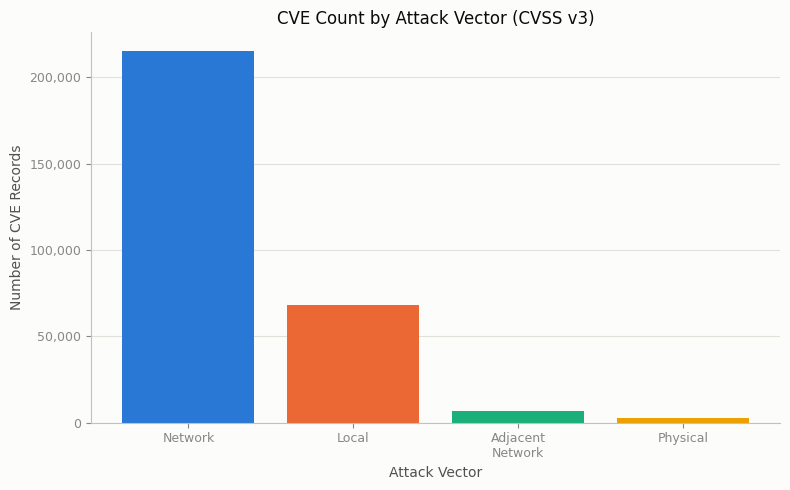

In [8]:
# Bar chart: how common each attack vector is in the dataset.
av_order = ["NETWORK", "LOCAL", "ADJACENT_NETWORK", "PHYSICAL"]
av_labels = ["Network", "Local", "Adjacent\nNetwork", "Physical"]
av_counts = df["v3_attack_vector"].value_counts().reindex(av_order)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(av_labels, av_counts.values, color=CAT[:4])
ax.set_title("CVE Count by Attack Vector (CVSS v3)")
ax.set_xlabel("Attack Vector")
ax.set_ylabel("Number of CVE Records")
style_ax(ax)
thousands(ax)
plt.show()

**Reading this chart:** Most scored CVEs are exploitable over a network, not just a
handful. Combined with the previous chart showing Network-vector CVEs also have the
highest exploitability scores, this is the group of vulnerabilities a patch-prioritization
program should treat as the default high-attention case.


### 3.3 Relationships


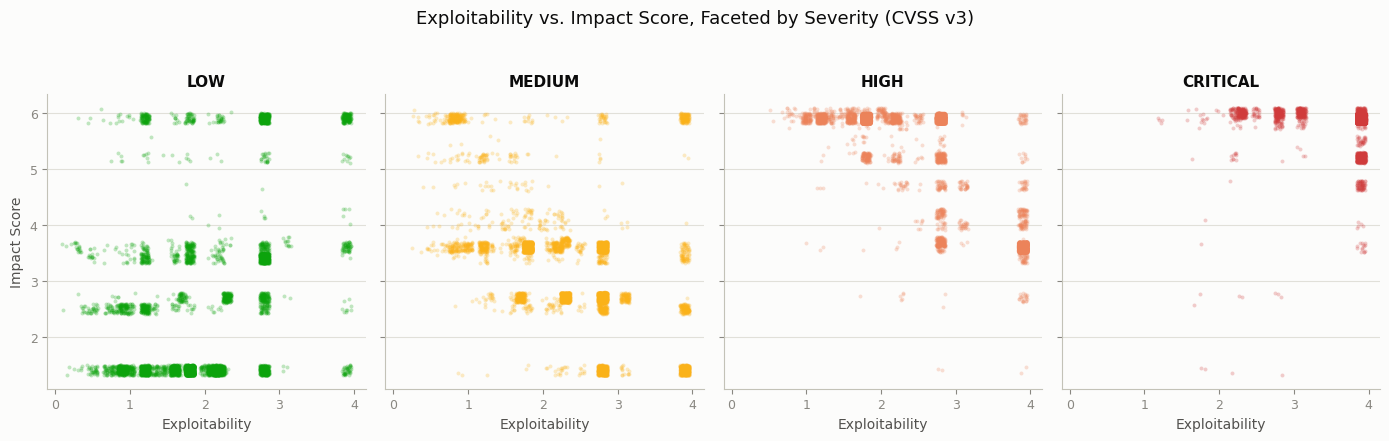

In [9]:
# Faceted scatter: how the two CVSS v3 sub-scores that make up overall severity
# relate, split into one small panel per severity category instead of one crowded
# plot. A single combined scatter here turned into an overplotted grid (CVSS
# sub-scores only take a fixed set of values, so points stack on top of each
# other) with four semi-transparent colors fighting for the same space. Faceting
# keeps every group on its own axes, and a small amount of jitter is added so
# points spread out instead of stacking exactly on the grid lines.
plot_sample = df.dropna(subset=["v3_exploitability_score", "v3_impact_score", "primary_severity"])
plot_sample = plot_sample[plot_sample["primary_severity"].isin(SEVERITY_ORDER)]
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 4, figsize=(14, 4.2), sharex=True, sharey=True)
for ax, sev in zip(axes, SEVERITY_ORDER):
    g = plot_sample[plot_sample["primary_severity"] == sev]
    if len(g) > 6000:
        g = g.sample(6000, random_state=42)
    jitter_x = rng.uniform(-0.06, 0.06, size=len(g))
    jitter_y = rng.uniform(-0.09, 0.09, size=len(g))
    ax.scatter(g["v3_exploitability_score"] + jitter_x, g["v3_impact_score"] + jitter_y,
               s=8, alpha=0.25, color=STATUS[sev], linewidths=0)
    ax.set_title(sev, color=STATUS[sev], fontsize=11, fontweight="bold")
    ax.set_xlabel("Exploitability")
    style_ax(ax)
axes[0].set_ylabel("Impact Score")
fig.suptitle("Exploitability vs. Impact Score, Faceted by Severity (CVSS v3)",
             color=INK_PRIMARY, fontsize=13, y=1.04)
plt.show()

**Reading this chart:** Splitting into one panel per severity makes the pattern much
easier to see than a single overlapping scatter did. LOW (far left panel) sits almost
entirely in the lower-left, meaning both low exploitability and low impact. Moving panel
by panel toward CRITICAL (far right), the cloud of points steadily shifts up and to the
right, toward high exploitability and high impact together. CRITICAL is not being driven
by one sub-score spiking while the other stays low, both tend to be high at once. That
matters for Micro-Project 3: it is a sign that exploitability and impact will both carry
real, independent signal in a regression model rather than one of them being redundant.


### 3.4 Change Over Time


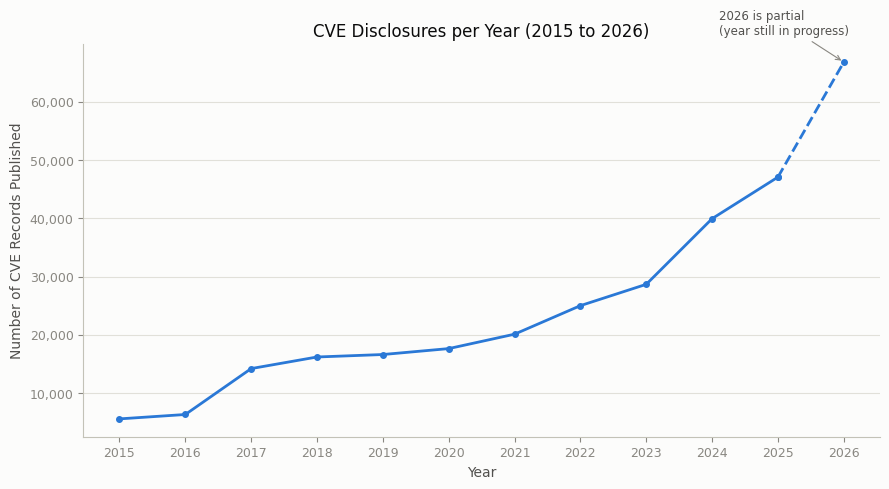

In [10]:
# Line chart: CVE disclosures per year. The current year is shown dashed and
# annotated since it is still in progress and will not match a full year's total yet.
yearly = df.groupby("published_year").size()
current_year = pd.Timestamp.now().year

fig, ax = plt.subplots(figsize=(9, 5))
complete = yearly[yearly.index < current_year]
partial = yearly[yearly.index >= current_year - 1]
ax.plot(complete.index, complete.values, color=CAT[0], linewidth=2, marker="o", markersize=4)
ax.plot(partial.index, partial.values, color=CAT[0], linewidth=2, linestyle="--",
        marker="o", markersize=4)
ax.set_title("CVE Disclosures per Year (2015 to 2026)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of CVE Records Published")
style_ax(ax)
thousands(ax)
ax.set_xticks(yearly.index)
ax.annotate(f"{current_year} is partial\n(year still in progress)",
            xy=(current_year, yearly[current_year]), xytext=(-90, 20),
            textcoords="offset points", fontsize=8.5, color=INK_SECONDARY,
            arrowprops=dict(arrowstyle="->", color=INK_MUTED, lw=0.8))
plt.show()

**Reading this chart:** Annual CVE disclosures have grown roughly twelve-fold since
2015, and the growth is accelerating rather than leveling off. Even with several months of
2026 still remaining, that partial year has already surpassed the full-year total for
2025. This is the clearest evidence in the whole notebook for the problem statement: the
volume a security team has to triage is not just large, it is growing faster every year,
which is exactly what makes manual, un-prioritized patching unsustainable.


Saved figures/monthly_cve_volume.png (static version for the knitted PDF)


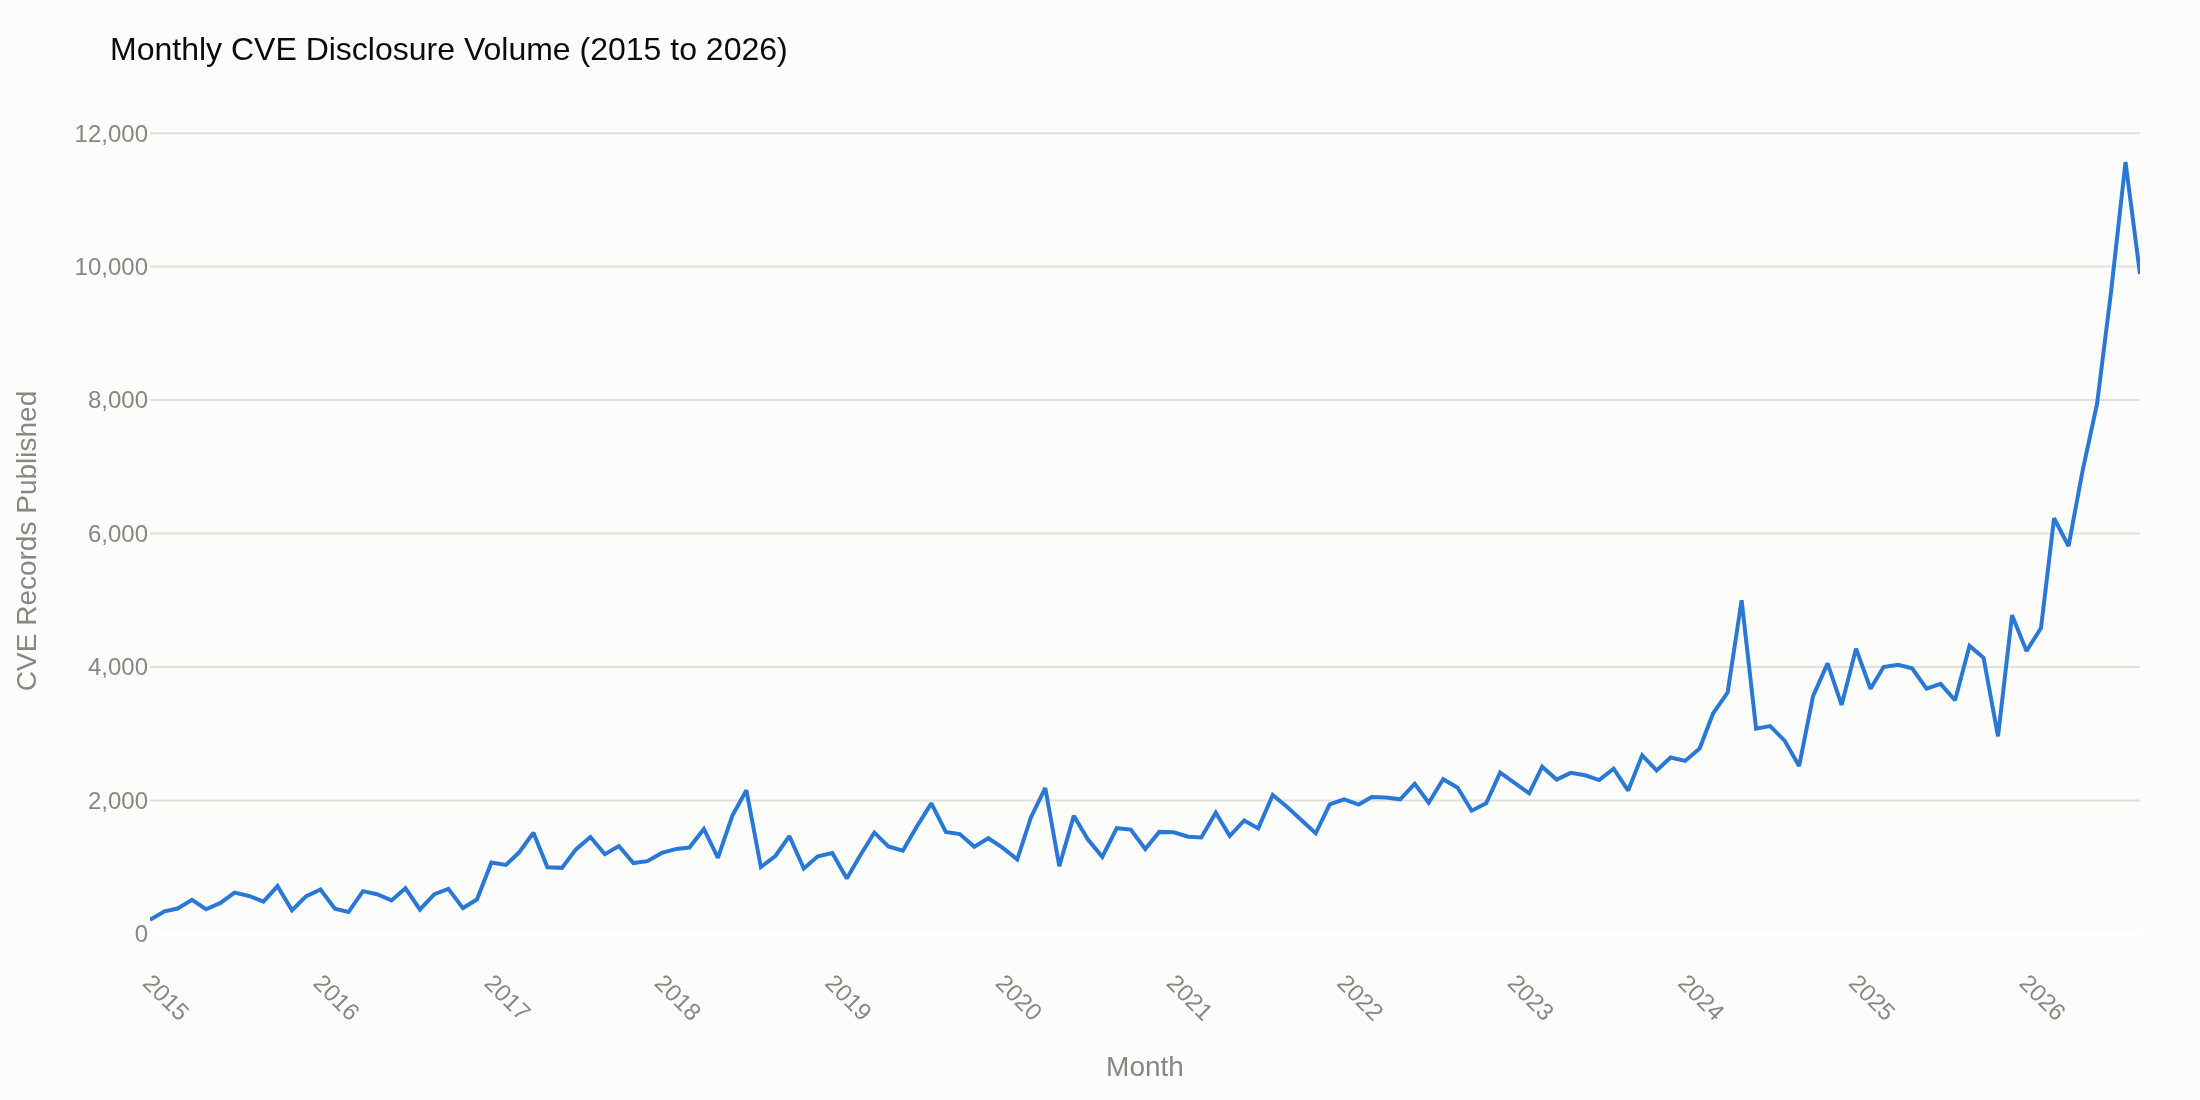

In [11]:
# Interactive Plotly line chart: same story at monthly resolution, which shows
# the recent acceleration in far more detail than the yearly view above can.
monthly = df.groupby("published_year_month").size().reset_index(name="count")
monthly = monthly.sort_values("published_year_month")

fig = px.line(
    monthly, x="published_year_month", y="count",
    title="Monthly CVE Disclosure Volume (2015 to 2026)",
    labels={"published_year_month": "Month", "count": "CVE Records Published"},
)
fig.update_traces(line_color=CAT[0], line_width=2,
                   hovertemplate="%{x}<br>%{y:,} CVEs<extra></extra>")
fig.update_layout(
    **PLOTLY_LAYOUT,
    xaxis=dict(showgrid=False, nticks=12, tickangle=45, color=INK_MUTED),
    yaxis=dict(gridcolor=GRIDLINE, color=INK_MUTED, tickformat=","),
)
fig.show()

# Plotly's interactive output only renders in a live Jupyter session. A knitted
# PDF/Word export cannot execute JavaScript, so it saves and displays a static
# copy too, which is the version that will actually show up in the printed
# code PDF submitted for this micro-project.
os.makedirs("figures", exist_ok=True)
pio.write_image(fig, "figures/monthly_cve_volume.png", width=1100, height=550, scale=2)
print("Saved figures/monthly_cve_volume.png (static version for the knitted PDF)")

from IPython.display import Image, display
display(Image("figures/monthly_cve_volume.png"))

**Reading this chart:** The monthly view (hover over any point in Jupyter to see
the exact month and count) shows the growth is not smooth. There is a sharp spike in mid-
2024 and then a much larger, sustained surge starting in early 2026 that dwarfs anything
earlier in the series. A sudden change like that is exactly the kind of pattern Micro-
Project 4's time-series forecasting will need to account for, since a simple straight-line
trend would badly underestimate what is coming.


### 3.5 Part-to-Whole


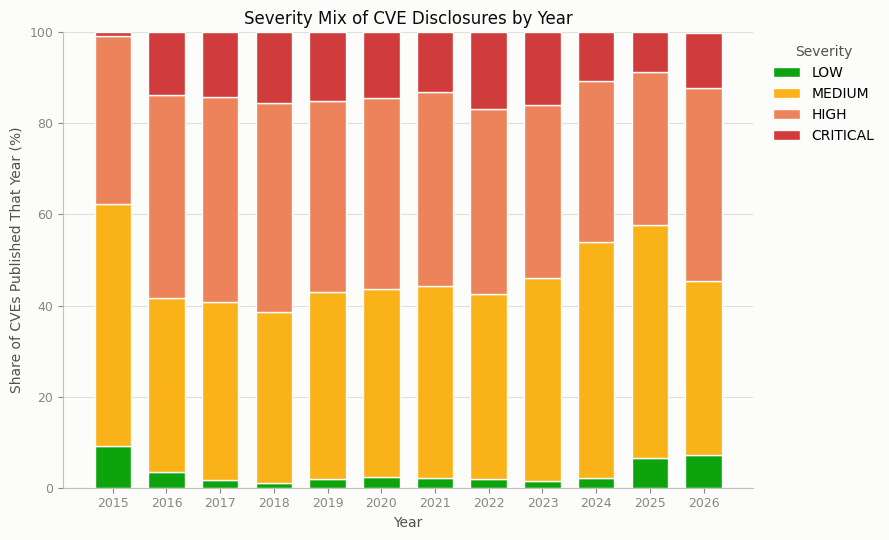

In [12]:
# Stacked bar chart: not just how many CVEs per year, but what share of each
# year's CVEs fell into each severity category. This checks the second half of the
# hypothesis: is the mix getting more severe, not just bigger.
comp = pd.crosstab(df["published_year"], df["primary_severity"], normalize="index") * 100
comp = comp.reindex(columns=SEVERITY_ORDER).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5.5))
bottom = np.zeros(len(comp))
for sev in SEVERITY_ORDER:
    ax.bar(comp.index, comp[sev], bottom=bottom, color=STATUS[sev], label=sev,
           width=0.68, edgecolor=SURFACE, linewidth=1)
    bottom += comp[sev].values
ax.set_title("Severity Mix of CVE Disclosures by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Share of CVEs Published That Year (%)")
style_ax(ax)
ax.set_xticks(comp.index)
ax.set_ylim(0, 100)
leg = ax.legend(title="Severity", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
leg.get_title().set_color(INK_SECONDARY)
plt.show()

**Reading this chart:** The CRITICAL share (dark red, top of each bar) has
generally grown since 2015, and the LOW share (green, bottom of each bar) has stayed thin
in every year. Combined with the previous two charts, this means the growing flood of CVEs
is not being diluted by a lot of harmless, low-severity noise. A meaningful and fairly
steady share of it is genuinely serious, which reinforces why prioritization, not just
raw throughput, is the right framing for the problem statement.


### 3.6 Heatmaps and Correlation


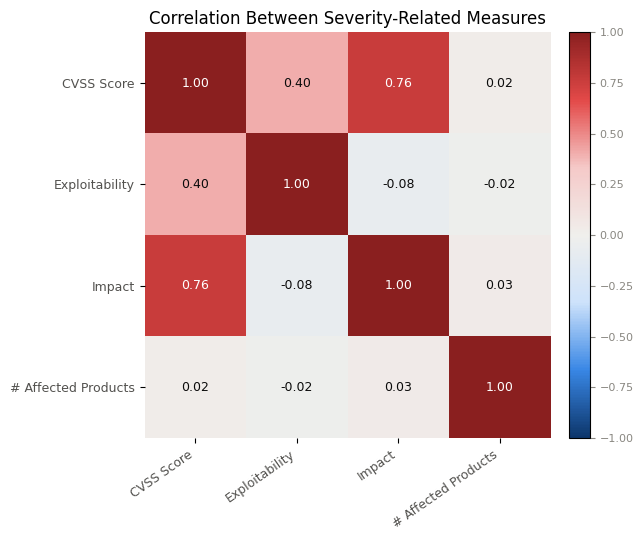

In [13]:
# Correlation heatmap across the numeric severity-related measures, to scan for
# which pairs of measures move together before deciding what goes into a regression
# model in Micro-Project 3.
num_cols = ["primary_score", "v3_exploitability_score", "v3_impact_score", "num_affected_products"]
labels = ["CVSS Score", "Exploitability", "Impact", "# Affected Products"]
corr = df[num_cols].corr()

cmap = LinearSegmentedColormap.from_list("div", DIV_BLUE_RED)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha="right", color=INK_SECONDARY, fontsize=9)
ax.set_yticklabels(labels, color=INK_SECONDARY, fontsize=9)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = corr.values[i, j]
        txt_color = "#ffffff" if abs(v) > 0.55 else INK_PRIMARY
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, color=txt_color)
ax.set_title("Correlation Between Severity-Related Measures")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(colors=INK_MUTED, labelsize=8)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

**Reading this chart:** The overall CVSS score correlates strongly with Impact
(0.76) and moderately with Exploitability (0.40), confirming both sub-scores feed into the
final score but Impact carries more weight in practice. Exploitability and Impact
themselves are only weakly related to each other (-0.08), meaning they capture genuinely
different information, which is a good sign for using both as separate predictors later.
Number of affected products barely correlates with anything here (near 0 across the row),
so it looks more useful as a supporting detail than a severity predictor on its own.


## Step 4: Report

**Summary of findings.** CVE disclosure volume has grown roughly twelve-fold since 2015
and is still accelerating, with monthly data showing a sharp, sustained surge starting in
early 2026 that a simple straight-line trend would not have predicted. This growth is not
being diluted by harmless records: MEDIUM and HIGH severity CVEs make up the large
majority of the dataset, CRITICAL CVEs alone total over 38,000 records, and the CRITICAL
share of each year's disclosures has generally grown rather than shrunk. On the structural
side of the hypothesis, attack vector clearly relates to exploitability: CVEs reachable
over a Network are both the most common category and the easiest to exploit by CVSS's own
scoring, while overall severity is driven by a combination of the exploitability and
impact sub-scores rather than either one alone, and those two sub-scores are only weakly
related to each other. Vendor-level CVE counts are dominated by large, widely used
platforms (Linux, Microsoft, Oracle, Google), which reflects how much scrutiny their
software receives rather than how well or poorly it was built, so raw vendor CVE counts
should not be read as a quality ranking on their own.

**Connection back to the problem statement and hypothesis.** The problem statement asked
how a security team should prioritize patching and plan analyst capacity against a
constantly growing pile of CVEs. These charts show the pile is not just growing, it is
growing faster each year and staying meaningfully severe as it grows, which is exactly the
condition that makes ad hoc, first-come-first-served patching unsustainable. The
hypothesis that structural CVSS characteristics relate to severity held up under this
visual exploration, particularly for attack vector and the exploitability/impact split,
both of which look like usable, well-behaved predictors going into Micro-Project 3's
regression modeling. The accelerating and uneven month-to-month growth pattern also
previews why Micro-Project 4 will need a model built for time-series forecasting rather
than a flat trend line.

**Scope note.** Per the Micro-Project 2 assignment, this notebook stops at the Report
step. Building a predictive model from these patterns (Analyze with regression) and
translating the results into a concrete patch-prioritization recommendation (Act) are
deliberately left to Micro-Projects 3 and 4, which continue with this same dataset.
